# 📈 Stock Analysis: AAPL

## Objective
Analyze historical stock performance for Apple (AAPL):
- Price trends
- Daily returns
- Volatility

## Why this matters
Understanding return behavior and volatility is foundational for equity analysis and risk management.

In [1]:
## This checks the Python executable
import sys
print(sys.executable)

/usr/bin/python


In [2]:
## This checks the Python version
import sys
print(sys.version)

3.12.8 (main, Nov 10 2011, 15:00:00) [GCC 14.2.0]


In [3]:
## This checks the installed packages
!pip list | head -20

Package                 Version
----------------------- -------------------
asarPy                  1.0.1
asttokens               3.0.1
beautifulsoup4          4.14.3
certifi                 2026.4.22
cffi                    2.0.0
charset-normalizer      3.4.7
comm                    0.2.3
contourpy               1.3.3
curl_cffi               0.15.0
cycler                  0.12.1
Cython                  3.0.11
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fonttools               4.62.1
frozendict              2.4.7
idna                    3.13
ipykernel               7.2.0
ERROR: Pipe to stdout was broken


In [4]:
## This does a targeted check of installed packages
!pip show pandas
!pip show matplotlib
!pip show yfinance

Name: pandas
Version: 3.0.2
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

 Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
 All rights reserved.

 Copyright (c) 2011-2026, Open source contributors.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contribut

In [5]:
## This checks the working directory
import os
print(os.getcwd())

/home/jflores/Documents/github-projects/jupyter-notebook-practice/notebooks


In [6]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [7]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [8]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [9]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2025-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [10]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.517254,153.040436,149.818775,151.362795,9.057103e+07
std,41.890558,42.031052,41.667657,41.834312,5.324438e+07
min,54.213608,55.211524,51.372088,55.110042,2.323470e+07
25%,126.395454,127.514439,124.393024,125.840219,5.546825e+07
50%,150.106773,151.849530,148.173566,149.926893,7.628335e+07
75%,176.064095,177.615915,174.497875,175.870097,1.077425e+08
max,257.612701,258.686851,256.230269,256.787224,4.265100e+08


In [11]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [12]:
# Choose the correct price column
price_col = "Adj Close" if "Adj Close" in data.columns else "Close"

print("Using price column:", price_col)

data["returns"] = data[price_col].pct_change()
data.head()

Using price column: Close


Price,Close,High,Low,Open,Volume,returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,NaN
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800,-0.009722
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200,0.007968
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000,-0.004703
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200,0.016086


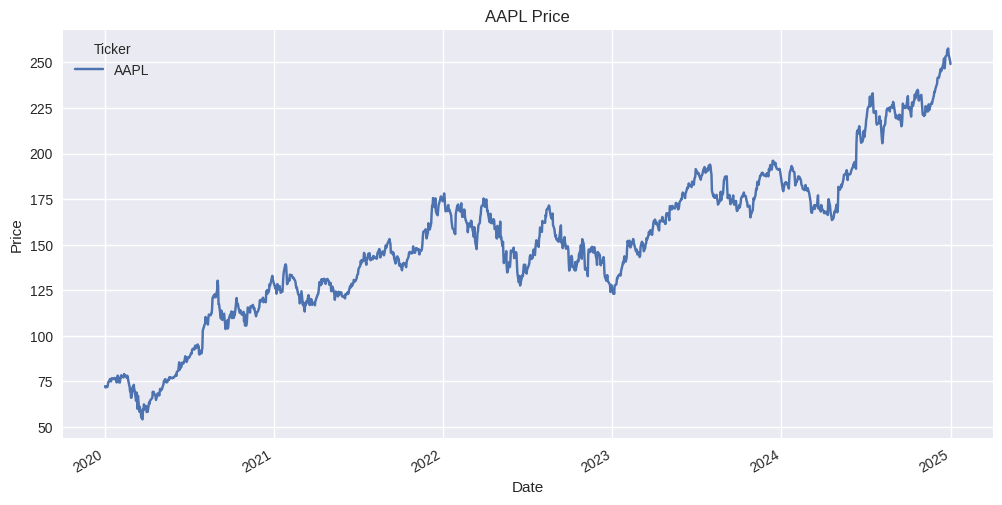

In [13]:
data[price_col].plot(figsize=(12, 6), title=f"{ticker} Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

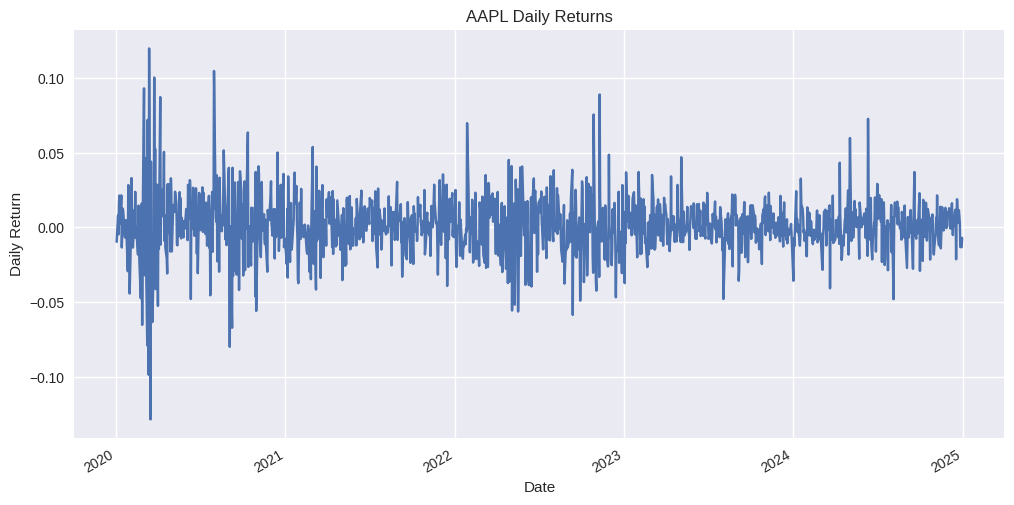

In [14]:
data["returns"].plot(figsize=(12, 6), title=f"{ticker} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

In [15]:
daily_volatility = data["returns"].std()
annualized_volatility = daily_volatility * (252 ** 0.5)

print("Daily volatility:", daily_volatility)
print("Annualized volatility:", annualized_volatility)

Daily volatility: 0.019955662323411692
Annualized volatility: 0.3167863185319724


## Volatility

Daily volatility measures how much the stock’s daily returns move around their average.

Annualized volatility scales daily volatility by the square root of 252, which is a common approximation for the number of trading days in a year.

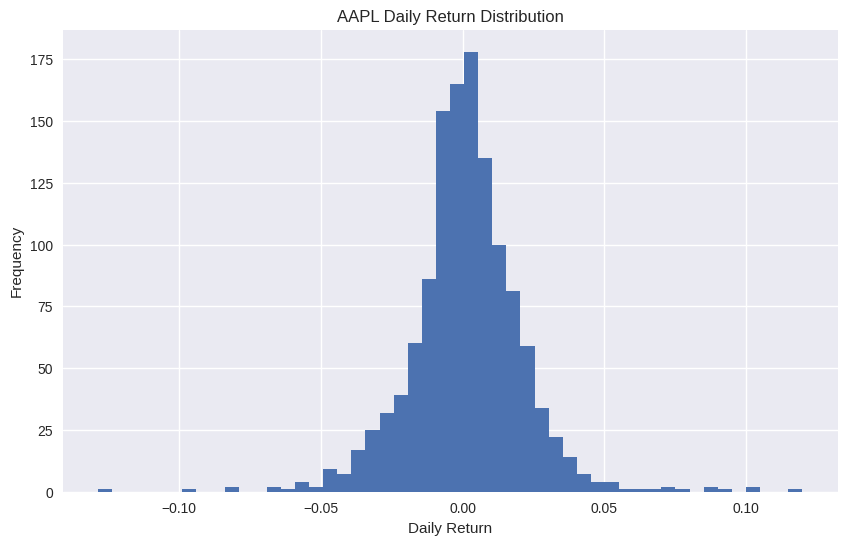

In [16]:
data["returns"].hist(bins=50, figsize=(10, 6))
plt.title(f"{ticker} Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

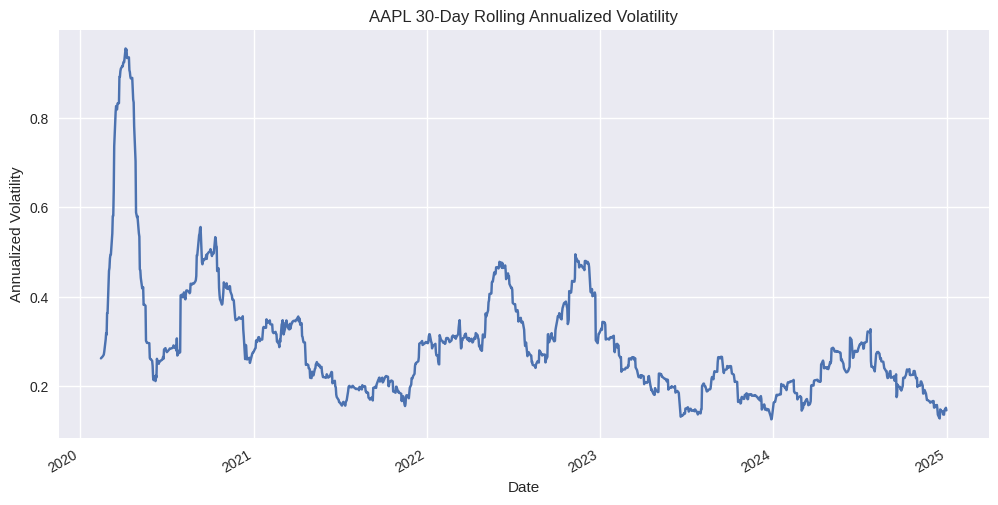

In [17]:
data["rolling_30d_vol"] = data["returns"].rolling(30).std() * (252 ** 0.5)

data["rolling_30d_vol"].plot(figsize=(12, 6), title=f"{ticker} 30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.show()

In [18]:
summary_stats = data["returns"].describe()
summary_stats

count    1257.000000
mean        0.001182
std         0.019956
min        -0.128647
25%        -0.008425
50%         0.001187
75%         0.011989
max         0.119809
Name: returns, dtype: float64

## Key Insights

- The stock price trend shows how AAPL performed over the selected period.
- Daily returns are centered around zero, which is typical for liquid equities.
- The return distribution shows periods of larger positive and negative moves.
- Rolling volatility changes over time, showing that risk is not constant.
- This notebook provides a basic framework for analyzing price, return, and volatility behavior.